# Freddie Mac — Final 10F CatBoost threshold selection

Select the decision threshold from **5-fold out-of-fold predictions on the training split**. Keep the held-out test set untouched until the threshold has been fixed. The saved fitted 10F model is loaded for the final test evaluation; its parameters and weights are not changed. The previous threshold `0.015` is evaluated only as a reference and is excluded from the threshold search.

Run all cells in order. A 5-fold refit takes time. All code and comments are in English.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             average_precision_score, roc_auc_score, confusion_matrix)
from helpers import *

PROJECT_ROOT = Path(
    r"C:\Users\itwill\Desktop\study\코딩공부\프로젝트"
    r"\The Single Family Loan-Level Dataset (SFLLD) - 6"
)
MODEL_PATH = (PROJECT_ROOT / "notebooks" /
    "SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams" /
    "importance" / "catboost_no_harp_10F_fixed.pkl")
DATA_PATH = (PROJECT_ROOT / "data" / "output" / "model_ready" /
    "SFLLD_regular_PIT_train_ML_ready.parquet")
OUTPUT_DIR = MODEL_PATH.parent / "threshold_selection"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 3217
REFERENCE_THRESHOLD = 0.015
THRESHOLD_MIN = 0.2
THRESHOLD_MAX = 0.7
THRESHOLD_STEP = 0.0005

for path in (MODEL_PATH, DATA_PATH):
    if not path.is_file():
        raise FileNotFoundError(path)

estimator = my_ml.load_model(MODEL_PATH)
df = pd.read_parquet(DATA_PATH)
print("Model:", MODEL_PATH)
print("Data:", DATA_PATH, df.shape)
print("Results:", OUTPUT_DIR)

Model: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\catboost_no_harp_10F_fixed.pkl
Data: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready\SFLLD_regular_PIT_train_ML_ready.parquet (160003, 56)
Results: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\threshold_selection


In [2]:
FEATURES_10F = [
    "FICO_Score", "Original_DTI", "Original_CLTV", "Original_Interest_Rate",
    "Number_of_Borrowers", "Housing_HPI_Growth_12M",
    "BLS_Unemployment_Rate_Change_12M_Final", "DTI_Missing",
    "Spatial_Cluster_Region", "Regular_MSA_Macro_Cluster_A",
]
CATEGORICAL_10F = [
    "DTI_Missing", "Spatial_Cluster_Region", "Regular_MSA_Macro_Cluster_A",
]
assert set(FEATURES_10F + ["Target_24M"]).issubset(df.columns)
df = my_qtcheck.set_type(df, as_category=CATEGORICAL_10F)
X = df[FEATURES_10F].copy()
y = df["Target_24M"].astype(int).copy()
assert set(y.unique()) == {0, 1}
assert not X.isna().any().any()
for col in CATEGORICAL_10F:
    assert isinstance(X[col].dtype, pd.CategoricalDtype), (col, X[col].dtype)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
model_features = list(estimator.named_steps["model"].feature_names_)
assert model_features == FEATURES_10F, (model_features, FEATURES_10F)
print("Train:", x_train.shape, "Test:", x_test.shape)
print("Positive events:", int(y_train.sum()), int(y_test.sum()))
print("Categorical dtypes:\n", x_train[CATEGORICAL_10F].dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 160003 entries, 0 to 160002
Data columns (total 56 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Loan_ID                                 160003 non-null  str           
 1   FICO_Score                              160003 non-null  float64       
 2   First_Payment_Date                      160003 non-null  datetime64[us]
 3   First_Time_Homebuyer                    160003 non-null  int64         
 4   Maturity_Date                           160003 non-null  datetime64[us]
 5   MSA                                     160003 non-null  int64         
 6   MI_Percentage                           160003 non-null  float64       
 7   Number_of_Units                         160003 non-null  int64         
 8   Occupancy_Status                        160003 non-null  int64         
 9   Original_CLTV                           160003 n

## 1. Generate out-of-fold training predictions

Each fold fits a fresh clone of the fixed 10F pipeline on four fifths of the training split, then predicts the remaining fifth. The held-out test split is never used here. This is threshold selection, not hyperparameter search.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_probability = np.full(len(x_train), np.nan)
fold_id = np.full(len(x_train), -1, dtype=int)

for fold, (train_idx, valid_idx) in enumerate(cv.split(x_train, y_train), start=1):
    fold_model = clone(estimator)
    fold_model.fit(
        x_train.iloc[train_idx], y_train.iloc[train_idx],
        model__cat_features=CATEGORICAL_10F,
    )
    oof_probability[valid_idx] = fold_model.predict_proba(x_train.iloc[valid_idx])[:, 1]
    fold_id[valid_idx] = fold
    print(f"Fold {fold}/5 completed: validation rows={len(valid_idx):,}")

assert np.isfinite(oof_probability).all()
assert (fold_id > 0).all()
print("OOF PR-AUC:", average_precision_score(y_train, oof_probability))
print("OOF ROC-AUC:", roc_auc_score(y_train, oof_probability))

Fold 1/5 completed: validation rows=25,601
Fold 2/5 completed: validation rows=25,601
Fold 3/5 completed: validation rows=25,600
Fold 4/5 completed: validation rows=25,600
Fold 5/5 completed: validation rows=25,600
OOF PR-AUC: 0.03611969258549419
OOF ROC-AUC: 0.8296434476577685


## 2. Search thresholds from 0.2 to 0.7

The sweep uses increments of 0.0005, excluding 0.015; the old threshold is reported separately. Select the largest F1; ties favor higher recall, then the lower threshold. Edit the three range constants above to expand or refine the search. PR-AUC and ROC-AUC do not depend on the classification threshold.

In [4]:
thresholds = np.arange(
    THRESHOLD_MIN, THRESHOLD_MAX + THRESHOLD_STEP / 2, THRESHOLD_STEP
).round(6)
assert THRESHOLD_MIN <= thresholds.min() <= thresholds.max() <= THRESHOLD_MAX + 1e-10
assert not np.isclose(thresholds, REFERENCE_THRESHOLD).any()
y_oof = y_train.to_numpy()
rows = []
for threshold in thresholds:
    pred = (oof_probability >= threshold).astype(int)
    tp = int(((pred == 1) & (y_oof == 1)).sum())
    fp = int(((pred == 1) & (y_oof == 0)).sum())
    fn = int(((pred == 0) & (y_oof == 1)).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0.0
    rows.append({"Threshold": threshold, "F1": f1, "Precision": precision,
                 "Recall": recall, "Predicted_Positive": int(pred.sum()),
                 "TP": tp, "FP": fp, "FN": fn})

sweep = pd.DataFrame(rows)
ranked = sweep.sort_values(
    ["F1", "Recall", "Threshold"], ascending=[False, False, True]
).reset_index(drop=True)
best_threshold = float(ranked.loc[0, "Threshold"])
print("Best OOF F1 threshold:", best_threshold)
display(ranked.head(15))
reference_pred = (oof_probability >= REFERENCE_THRESHOLD).astype(int)
reference_row = {"Threshold": REFERENCE_THRESHOLD,
                 "F1": f1_score(y_oof, reference_pred, zero_division=0),
                 "Precision": precision_score(y_oof, reference_pred, zero_division=0),
                 "Recall": recall_score(y_oof, reference_pred, zero_division=0),
                 "Predicted_Positive": int(reference_pred.sum())}
print("Reference threshold (excluded from search):")
display(pd.DataFrame([reference_row]))
if ranked.loc[0, "F1"] == 0:
    print("WARNING: All candidate thresholds have OOF F1 = 0. The selected threshold is only a tie-break result, not an effective classifier.")
sweep.to_csv(OUTPUT_DIR / "threshold_sweep_oof.csv", index=False)

if best_threshold in (thresholds.min(), thresholds.max()):
    print("Boundary optimum: consider extending THRESHOLD_MIN or THRESHOLD_MAX.")

Best OOF F1 threshold: 0.2


,Threshold,F1,Precision,Recall,Predicted_Positive,TP,FP,FN
0,0.2000,0.0,0.0,0.0,14,0,14,735
1,0.2005,0.0,0.0,0.0,14,0,14,735
2,0.2010,0.0,0.0,0.0,14,0,14,735
3,0.2015,0.0,0.0,0.0,14,0,14,735
4,0.2020,0.0,0.0,0.0,14,0,14,735
5,0.2025,0.0,0.0,0.0,14,0,14,735
6,0.2030,0.0,0.0,0.0,14,0,14,735
7,0.2035,0.0,0.0,0.0,14,0,14,735
8,0.2040,0.0,0.0,0.0,14,0,14,735
9,0.2045,0.0,0.0,0.0,14,0,14,735


Reference threshold (excluded from search):


,Threshold,F1,Precision,Recall,Predicted_Positive
0,0.015,0.056357,0.030066,0.44898,10976


Boundary optimum: consider extending THRESHOLD_MIN or THRESHOLD_MAX.


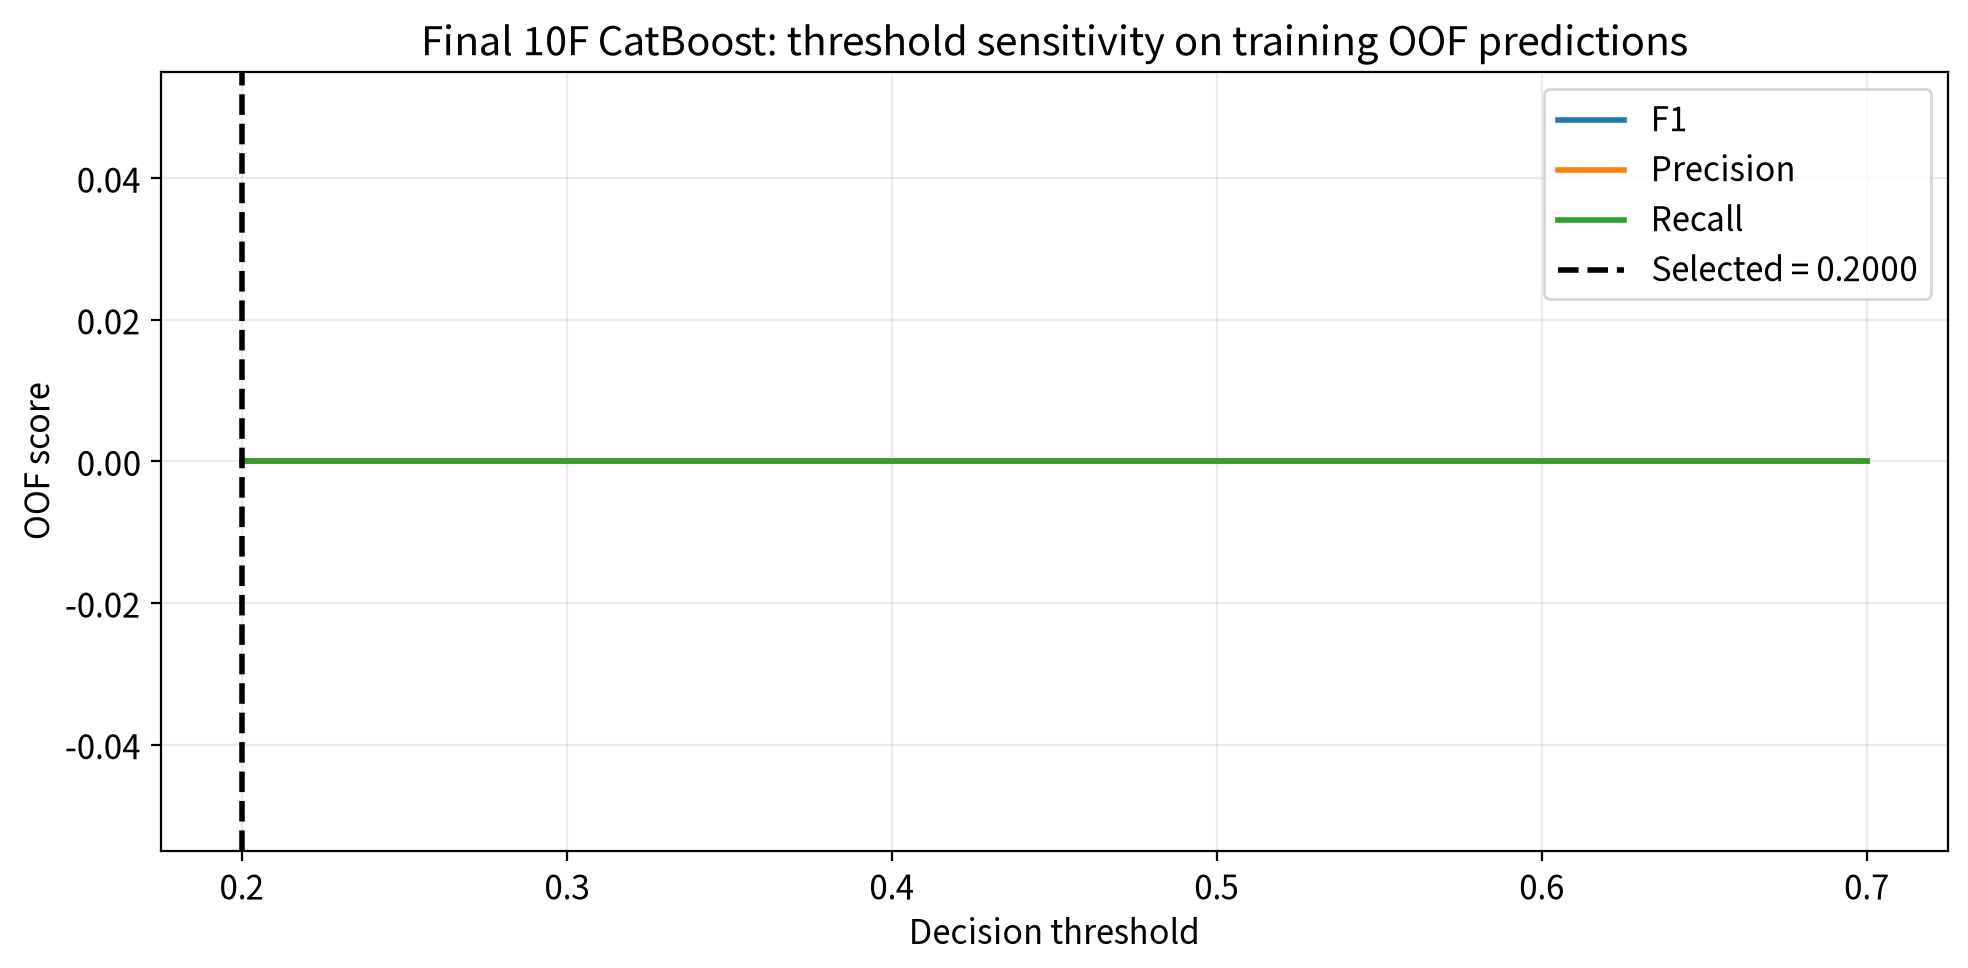

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for metric in ["F1", "Precision", "Recall"]:
    ax.plot(sweep.Threshold, sweep[metric], label=metric)
ax.axvline(best_threshold, color="black", linestyle="--",
           label=f"Selected = {best_threshold:.4f}")
if THRESHOLD_MIN <= REFERENCE_THRESHOLD <= THRESHOLD_MAX:
    ax.axvline(REFERENCE_THRESHOLD, color="gray", linestyle=":",
               label=f"Previous = {REFERENCE_THRESHOLD:.3f}")
ax.set(xlabel="Decision threshold", ylabel="OOF score",
       title="Final 10F CatBoost: threshold sensitivity on training OOF predictions")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "threshold_sensitivity_oof.png", dpi=160)
plt.show()

## 3. Evaluate the saved final model on held-out test once

The test set has not influenced `best_threshold`. The reference `0.015` result is displayed beside the selected threshold. Because threshold selection uses these OOF predictions, its maximum F1 is a selection estimate rather than an unbiased validation score. The held-out test row is the final check.

In [6]:
test_probability = estimator.predict_proba(x_test[FEATURES_10F])[:, 1]

def evaluate_at_threshold(y_true, probability, threshold):
    predicted = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    return {
        "Threshold": threshold,
        "F1": f1_score(y_true, predicted, zero_division=0),
        "Precision": precision_score(y_true, predicted, zero_division=0),
        "Recall": recall_score(y_true, predicted, zero_division=0),
        "Accuracy": accuracy_score(y_true, predicted),
        "PR_AUC": average_precision_score(y_true, probability),
        "ROC_AUC": roc_auc_score(y_true, probability),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "Predicted_Positive": int(predicted.sum()),
    }

report = pd.DataFrame([
    {"Dataset": "Train OOF", **evaluate_at_threshold(y_train, oof_probability, REFERENCE_THRESHOLD)},
    {"Dataset": "Train OOF", **evaluate_at_threshold(y_train, oof_probability, best_threshold)},
    {"Dataset": "Held-out test", **evaluate_at_threshold(y_test, test_probability, REFERENCE_THRESHOLD)},
    {"Dataset": "Held-out test", **evaluate_at_threshold(y_test, test_probability, best_threshold)},
])
display(report)
report.to_csv(OUTPUT_DIR / "threshold_final_comparison.csv", index=False)

with open(OUTPUT_DIR / "selected_threshold.json", "w", encoding="utf-8") as f:
    json.dump({
        "model_path": str(MODEL_PATH),
        "selection_dataset": "5-fold out-of-fold probabilities from training split",
        "primary_metric": "F1",
        "selected_threshold": best_threshold,
        "previous_threshold": REFERENCE_THRESHOLD,
        "threshold_min": THRESHOLD_MIN,
        "threshold_max": THRESHOLD_MAX,
        "threshold_step": THRESHOLD_STEP,
        "random_state": RANDOM_STATE,
        "test_size": 0.20,
        "features": FEATURES_10F,
    }, f, indent=2)
print("Saved results to:", OUTPUT_DIR)
print("The saved fitted model was not overwritten.")

,Dataset,Threshold,F1,Precision,Recall,Accuracy,PR_AUC,ROC_AUC,TN,FP,FN,TP,Predicted_Positive
0,Train OOF,0.015,0.056357,0.030066,0.448980,0.913665,0.03612,0.829643,116621,10646,405,330,10976
1,Train OOF,0.200,0.000000,0.000000,0.000000,0.994149,0.03612,0.829643,127253,14,735,0,14
2,Held-out test,0.015,0.062522,0.033474,0.472826,0.918471,0.04768,0.855422,29305,2512,97,87,2599
3,Held-out test,0.200,0.010695,0.333333,0.005435,0.994219,0.04768,0.855422,31815,2,183,1,3


Saved results to: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\notebooks\SFLLD_M8_11F_DTI_Missing_3models_controlled_fixed12Fparams\importance\threshold_selection
The saved fitted model was not overwritten.
